# 13F — análise exploratória v1

Base: `crowdflow/data/20_curated` — **58,0M posições, 397.833 filings, 16.327 filers, 2013Q2→2026Q1**,
validada em `crowdflow/docs/BASE_VALIDATION.md` (22/22).

**Disciplina point-in-time desta análise**: cada trimestre foi materializado via
`store.as_of(p, p + 70 dias)` — o que era público 70 dias após o fim do trimestre
(~95% dos originais). Exploração ≈ formação de portfólio; a esteira de produção usa o
calendário de ativação por cobertura. Nada aqui enxerga além do vantage.

Preparado por `prep_analysis_v1.py`; este notebook só lê os agregados e plota.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

DATA = "data"
plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

funds = pd.read_csv(f"{DATA}/funds_per_quarter.csv", parse_dates=["period_end"])
aum = pd.read_csv(f"{DATA}/aum_per_quarter.csv", parse_dates=["period_end"])
elig = pd.read_csv(f"{DATA}/eligibility_per_quarter.csv", parse_dates=["period_end"])
panel = pd.read_csv(f"{DATA}/imbalance_panel.csv.gz", parse_dates=["period_end"])
agg = pd.read_csv(f"{DATA}/imbalance_agg.csv", parse_dates=["period_end"])
splits = pd.read_csv(f"{DATA}/split_adjustments.csv", parse_dates=["period_end"])
print(f"{len(funds)} trimestres | painel de imbalance: {len(panel):,} stock-quarters")

C:\Users\lsilva\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\lsilva\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


52 trimestres | painel de imbalance: 402,582 stock-quarters


## 1. Quantidade de fundos ao longo do tempo

Dois cortes: quantos **arquivaram** um 13F-HR original para o trimestre, e quantos
estavam **visíveis no vantage** (filaram até p+70d). A distância entre as linhas são
os atrasados crônicos. O crescimento secular vem do threshold de $100M nunca ter
sido indexado à inflação — o universo de filers cresce mecanicamente.

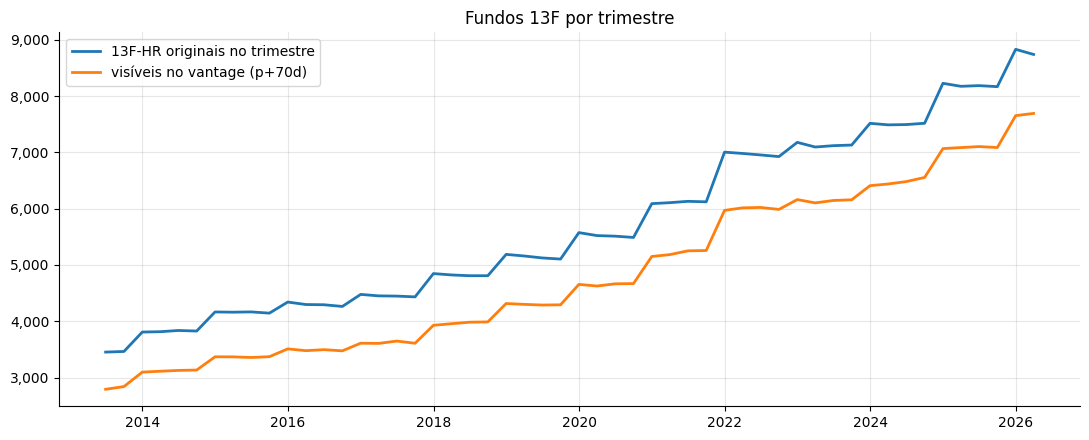

period_end  filers_visible  originals_filed
2025-06-30            7104             8187
2025-09-30            7087             8169
2025-12-31            7654             8832
2026-03-31            7693             8741


In [2]:
fig, ax = plt.subplots()
ax.plot(funds.period_end, funds.originals_filed, label="13F-HR originais no trimestre", lw=2)
ax.plot(funds.period_end, funds.filers_visible, label="visíveis no vantage (p+70d)", lw=2)
ax.set_title("Fundos 13F por trimestre")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend()
plt.tight_layout(); plt.show()
print(funds.tail(4).to_string(index=False))

## 2. "AUM" agregado ao longo do tempo

Aspas obrigatórias: 13F reporta só o **book long de equities/opções dos filers** —
sem shorts, sem bonds, sem caixa, sem posições < de minimis. É a melhor proxy pública
de capital institucional em equities US, não AUM de verdade.

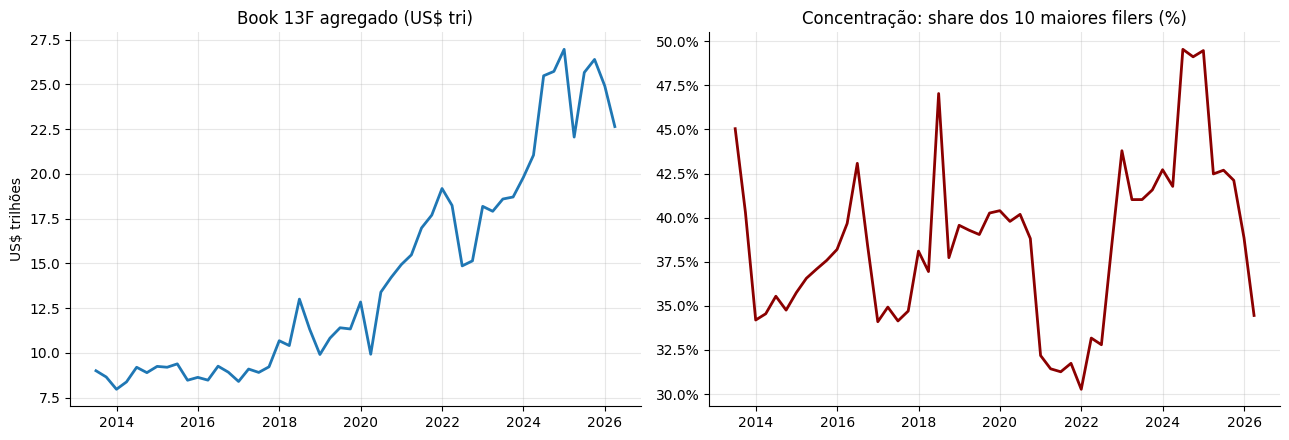

book total 2026-03-31: US$ 22.6 tri | top-10 share: 34%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(aum.period_end, aum.total_book_usd / 1e12, lw=2)
axes[0].set_title("Book 13F agregado (US$ tri)")
axes[0].set_ylabel("US$ trilhões")
axes[1].plot(aum.period_end, aum.top10_share * 100, lw=2, color="darkred")
axes[1].set_title("Concentração: share dos 10 maiores filers (%)")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()
print(f"book total {aum.period_end.iloc[-1].date()}: "
      f"US$ {aum.total_book_usd.iloc[-1]/1e12:.1f} tri | "
      f"top-10 share: {aum.top10_share.iloc[-1]:.0%}")

## 3. Universo dinâmico de fundos — a parte independente de preço

O universo do crowdflow filtra por elegibilidade e ranqueia por
impacto/centralidade/turnover. Impacto e centralidade precisam do painel de preços
(ADV, vol) — ainda pendente. O funil de **elegibilidade** já é computável só com a
base 13F: book ≥ $500M → ≥15 posições → top1 ≤ 60% → ≥4 trimestres de histórico.

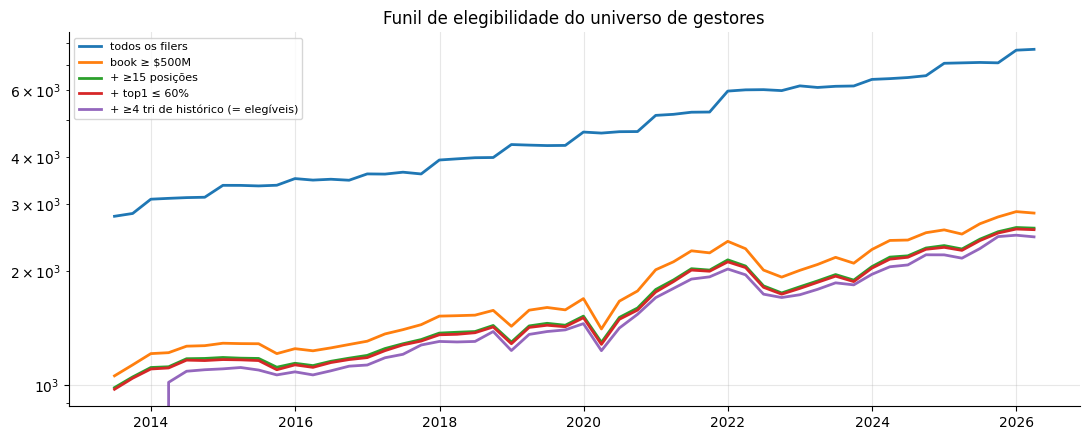

period_end  all_filers  book_ge_500m  and_ge_15_pos  and_top1_le_60  and_hist_ge_4q
2025-09-30        7087          2780           2541            2521            2467
2025-12-31        7654          2871           2607            2583            2488
2026-03-31        7693          2846           2597            2573            2463


In [4]:
fig, ax = plt.subplots()
for col, lbl in [("all_filers", "todos os filers"),
                 ("book_ge_500m", "book ≥ $500M"),
                 ("and_ge_15_pos", "+ ≥15 posições"),
                 ("and_top1_le_60", "+ top1 ≤ 60%"),
                 ("and_hist_ge_4q", "+ ≥4 tri de histórico (= elegíveis)")]:
    ax.plot(elig.period_end, elig[col], label=lbl, lw=2)
ax.set_title("Funil de elegibilidade do universo de gestores")
ax.set_yscale("log")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
print(elig.tail(3).to_string(index=False))

## 4. O sinal do paper — imbalances de Miori & Cucuringu (2022)

Por ação e trimestre, sobre o Δshares dos gestores presentes em **ambos** os
trimestres (senão o delta mede churn de filing, não trading):

- **TI** (trade-count) = (n_compras − n_vendas) / n_ativos — o herding puro;
- **VI** (volume) = (Σcompras − Σ|vendas|) / (Σcompras + Σ|vendas|);
- filtro de **≥10 gestores ativos** (o m do paper — TI=+1 com 1 fundo não é crowding);
- o paper opera **contra** o imbalance extremo (reversal de pressão de preço),
  melhor em 21–42 dias úteis, retorno relativo ao SPY, equal-weight nos top-quantis.

### Eventos corporativos: por que "normaliza, então tanto faz" está errado

13F reporta shares **as-filed**. Um split 4:1 multiplica o count de *todos* os
holders por 4 ao mesmo tempo → todo mundo vira "comprador" → TI → +1. A
normalização remove magnitude, **não um sinal compartilhado** — o split fabrica
consenso de compra perfeito. E shares outstanding do Yahoo não resolve: só existe o
valor corrente, não o histórico não-ajustado do dia.

A saída usada aqui (sem vendor): **os próprios holders são o detector, via átomo
modal**. A posição não-tocada tem ratio shares_t/shares_{t-1} = *exatamente* o fator
do split; quem também negociou se espalha ao redor. No 4:1 da AAPL (2.745 holders
comuns) o IQR dos ratios é 10% — qualquer teste de dispersão falha — mas 16,6% dos
holders caem em exatamente 4,00: um átomo que trading comum não produz, porque
centenas de gestores independentes nunca pousam no mesmo ratio exato ≠1 por escolha.
Regra (calibrada nos splits famosos, medidos): ratio modal (2 casas) fora de
[0,83; 1,2], aceito por **massa** (≥10% dos holders) *ou* por **dominância** (≥30
holders no átomo e ≥2,5× o segundo átomo) — necessária porque em mega-held names a
maioria dos holders negocia todo trimestre e a massa do átomo cai a 5-9% (AAPL 4:1:
167 de 2.745 holders em exatamente 4,00, contra 52 do vizinho). Abordagens sem tratamento de split
contornou o problema usando medidas por valor/contagem em nível; para Δshares o
ajuste é obrigatório.

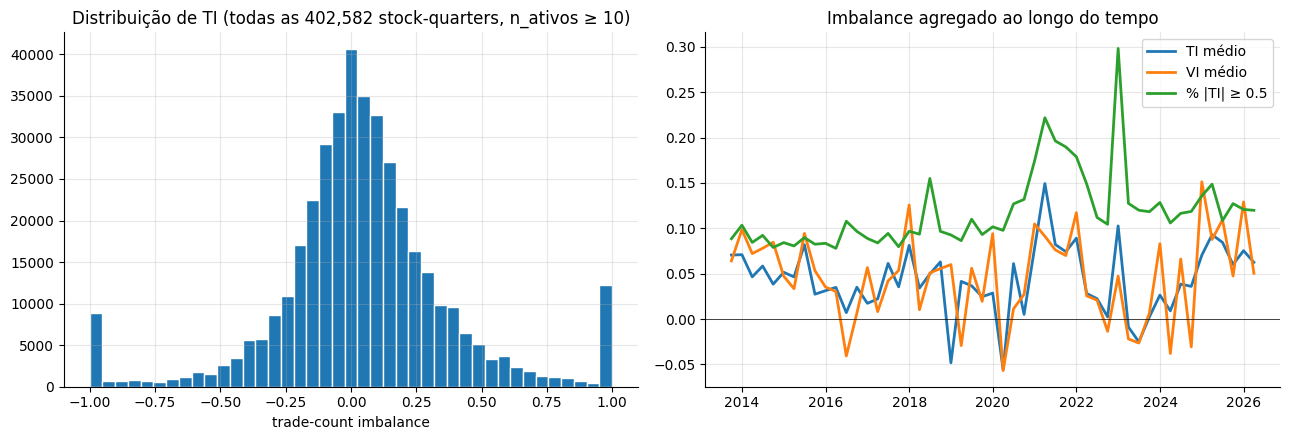

period_end  n_stocks  ti_mean  ti_median  vi_mean  pct_ti_extreme  n_active_median
2025-06-30     12075    0.084      0.076    0.110           0.109             36.0
2025-09-30     12288    0.060      0.059    0.047           0.127             35.0
2025-12-31     12462    0.075      0.059    0.129           0.121             34.0
2026-03-31     12813    0.063      0.054    0.050           0.120             35.0


C:\Users\lsilva\AppData\Local\Temp\ipykernel_60920\765930756.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(agg.tail(4).round(3).to_string(index=False))


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(panel.ti.dropna(), bins=41, edgecolor="white")
axes[0].set_title(f"Distribuição de TI (todas as {len(panel):,} stock-quarters, n_ativos ≥ 10)")
axes[0].set_xlabel("trade-count imbalance")
axes[1].plot(agg.period_end, agg.ti_mean, label="TI médio", lw=2)
axes[1].plot(agg.period_end, agg.vi_mean, label="VI médio", lw=2)
axes[1].plot(agg.period_end, agg.pct_ti_extreme, label="% |TI| ≥ 0.5", lw=2)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].set_title("Imbalance agregado ao longo do tempo")
axes[1].legend()
plt.tight_layout(); plt.show()
print(agg.tail(4).round(3).to_string(index=False))

O TI médio positivo é estrutural (instituições acumulam equities em agregado);
o sinal do paper é o **cross-section** — quem está no extremo relativo aos demais.
Os picos de dispersão marcam os trimestres de stress (2020Q1, 2022).

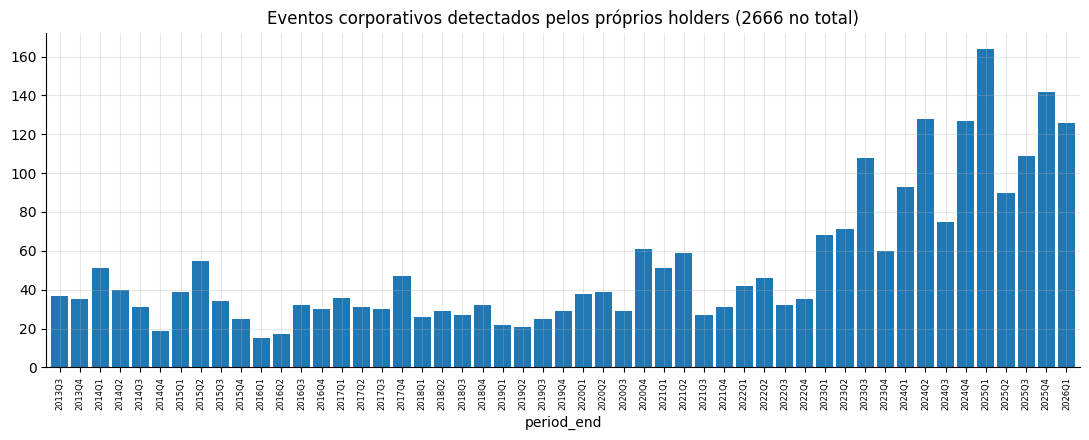

period_end instrument_id  ratio  n_holders  modal_mass                                  nome
2014-06-30     037833100    7.0       1538       0.092                   AAPL 4:1 (ago/2020)
2020-09-30     037833100    4.0       2745       0.061                   AAPL 4:1 (ago/2020)
2020-09-30     88160R101    5.0       1005       0.087                   TSLA 5:1 (ago/2020)
2021-09-30     67066G104    4.0       1949       0.121 NVDA 4:1 (jul/2021) e 10:1 (jun/2024)
2022-09-30     88160R101    3.0       2089       0.183                   TSLA 5:1 (ago/2020)
2024-06-30     67066G104   10.0       3090       0.057 NVDA 4:1 (jul/2021) e 10:1 (jun/2024)

maiores por nº de holders:
period_end instrument_id  ratio  n_holders  modal_mass
2022-06-30     023135106   20.0       3265       0.070
2024-06-30     67066G104   10.0       3090       0.057
2022-09-30     02079K305   20.0       2978       0.125
2020-09-30     037833100    4.0       2745       0.061
2022-09-30     02079K107   20.0       2682    

In [6]:
# diagnóstico do detector de eventos corporativos
per_q = splits.groupby(splits.period_end.dt.to_period("Q")).size()
fig, ax = plt.subplots()
per_q.plot(kind="bar", ax=ax, width=0.85)
ax.set_title(f"Eventos corporativos detectados pelos próprios holders ({len(splits)} no total)")
ax.set_xticklabels([str(x) for x in per_q.index], rotation=90, fontsize=6)
plt.tight_layout(); plt.show()
# prova de fogo: os splits famosos, pescados sem nenhum vendor
FAMOSOS = {"037833100": "AAPL 4:1 (ago/2020)", "88160R101": "TSLA 5:1 (ago/2020)",
           "67066G104": "NVDA 4:1 (jul/2021) e 10:1 (jun/2024)"}
hit = splits[splits.instrument_id.isin(FAMOSOS)]
hit = hit.assign(nome=hit.instrument_id.map(FAMOSOS))
print(hit.sort_values("period_end").to_string(index=False))
print("\nmaiores por nº de holders:")
print(splits.nlargest(8, "n_holders").to_string(index=False))

### Caveat honesto: os extremos ±1,0 têm poluição de troca de CUSIP

Nos top-consenso abaixo, vários nomes com TI = ±1,0 e centenas de gestores
"unânimes" são **o mesmo papel trocando de CUSIP** (reorganização, mudança de share
class): o identificador antigo vira 100% "venda" e o novo vira 100% "compra" — churn
de identificador, não trading. O detector de splits não pega (são instrumentos
diferentes). A correção é o crosswalk **datado** CUSIP→instrumento (CRSP `ncusip`),
já previsto na camada de identificadores do crowdflow. Até lá: extremos exatamente
±1,0 com muitos gestores merecem desconfiança — mais um argumento pro filtro de
quantil do paper em vez do extremo absoluto.

## 5. Onde o crowding está agora

Top consenso de compra e de venda no último trimestre do painel (TI, com o piso de
gestores ativos). Identificadores são CUSIPs — o crosswalk para ticker/nome entra
com o painel de preços.

In [7]:
last = panel[panel.period_end == panel.period_end.max()]
cols = ["instrument_id", "n_buy", "n_sell", "n_active", "ti", "vi"]
print(f"trimestre: {panel.period_end.max().date()}")
print("\n=== consenso de COMPRA (paper: candidatos a SHORT contrário) ===")
print(last[last.n_active >= 100].nlargest(10, "ti")[cols].round(3).to_string(index=False))
print("\n=== consenso de VENDA (paper: candidatos a LONG contrário) ===")
print(last[last.n_active >= 100].nsmallest(10, "ti")[cols].round(3).to_string(index=False))

trimestre: 2026-03-31

=== consenso de COMPRA (paper: candidatos a SHORT contrário) ===
instrument_id  n_buy  n_sell  n_active    ti    vi
    09290C764  129.0     0.0     129.0 1.000 1.000
    34631F102  132.0     0.0     132.0 1.000 1.000
    724078209  204.0     0.0     204.0 1.000 1.000
    866966104  219.0     0.0     219.0 1.000 1.000
    09290C855  186.0     2.0     188.0 0.979 0.999
    925283103  539.0     8.0     547.0 0.971 1.000
    09290C699  130.0     2.0     132.0 0.970 0.995
    6706EW100  141.0     3.0     144.0 0.958 0.987
    G0593M107  837.0    20.0     857.0 0.953 1.000
    72348N109  372.0    10.0     382.0 0.948 0.995

=== consenso de VENDA (paper: candidatos a LONG contrário) ===
instrument_id  n_buy  n_sell  n_active   ti   vi
    014491104    0.0   147.0     147.0 -1.0 -1.0
    05370A108    0.0   205.0     205.0 -1.0 -1.0
    12740C103    0.0   235.0     235.0 -1.0 -1.0
    15677J108    0.0   268.0     268.0 -1.0 -1.0
    171757206    0.0   149.0     149.0 -1.

## Próximos passos

1. **Backtest do sinal** na infra `factors/` (Yahoo): contrário aos top-quantis de
   |TI| e |VI|, horizontes 5/10/21/42/63d, retorno relativo ao SPY, equal-weight —
   a réplica fiel do paper, com o timing honesto do calendário de ativação;
2. sweep do filtro de gestores ativos (o paper mostra que mais atividade **não** é
   monotonicamente melhor) e dos quantis;
3. crosswalk CUSIP→ticker para casar com o painel Yahoo (e nomear os extremos acima);
4. cruzar com o universo dinâmico: TI calculado só sobre os top-25 transmissores de
   demanda vs. todos os filers — a tese do crowdflow em cima do sinal do paper.